In [1]:
import os
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
from jinja2 import Environment, FileSystemLoader
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, auc
import warnings

### VALIDAZIONE STATISTICA DEI DATI - analisi ASI

In [2]:
file_path = 'Dataset_Clinico_Pulito.csv' 
df_raw = pd.read_csv(file_path, encoding='latin1')

colonne_da_tenere = [
    'ID_Paziente', 
    'Gruppo', 
    'H&Y', 
    'ASI_Walk_HP (%)', 
    'ASI_Turn_HP (%)', 
    'ASI_Walk_SP (%)', 
    'ASI_Turn_SP (%)', 
    'ASI_Walk_TUG (%)', 
    'ASI_Turn_TUG (%)', 
    'Sesso', 
    'Eta'
]

df = df_raw[colonne_da_tenere].copy()

colonne_analisi = [
    'H&Y', 'ASI_Walk_HP (%)', 'ASI_Turn_HP (%)', 
    'ASI_Walk_SP (%)', 'ASI_Turn_SP (%)', 
    'ASI_Walk_TUG (%)', 'ASI_Turn_TUG (%)'
]

righe_iniziali = df.shape[0]
df_pulito = df.dropna(subset=colonne_analisi).reset_index(drop=True)
righe_finali = df_pulito.shape[0]

print(f"Righe originali: {righe_iniziali}")
print(f"Righe rimosse a causa di dati mancanti: {righe_iniziali - righe_finali}")
print(f"Dimensioni del dataset pulito finale: {df_pulito.shape[0]} righe e {df_pulito.shape[1]} colonne.")

Righe originali: 182
Righe rimosse a causa di dati mancanti: 7
Dimensioni del dataset pulito finale: 175 righe e 11 colonne.


In [3]:
tasks = ['HP', 'SP', 'TUG']

print("Risultati del T-Test di Welch sull'Indice ASI (%):")

for task in tasks:
    print(f"\nTASK: {task.upper()}")

    col_walk = f'ASI_Walk_{task} (%)'
    col_turn = f'ASI_Turn_{task} (%)'
    
    walk_pd = df[df['Gruppo'] == 'Parkinson'][col_walk].dropna()
    walk_hc = df[df['Gruppo'] == 'Sano'][col_walk].dropna()
    
    turn_pd = df[df['Gruppo'] == 'Parkinson'][col_turn].dropna()
    turn_hc = df[df['Gruppo'] == 'Sano'][col_turn].dropna()
    
    t_stat_walk, p_val_walk = stats.ttest_ind(walk_pd, walk_hc, equal_var=False)
    t_stat_turn, p_val_turn = stats.ttest_ind(turn_pd, turn_hc, equal_var=False)
    
    print("  [Fase WALK]")
    print(f"    Statistica t: {t_stat_walk:.4f}")
    print(f"    p-value:      {p_val_walk:.4f}")
    print(f"    Significativo (< 0.05): {p_val_walk < 0.05}")
    
    print("  [Fase TURN]")
    print(f"    Statistica t: {t_stat_turn:.4f}")
    print(f"    p-value:      {p_val_turn:.4f}")
    print(f"    Significativo (< 0.05): {p_val_turn < 0.05}")

Risultati del T-Test di Welch sull'Indice ASI (%):

TASK: HP
  [Fase WALK]
    Statistica t: 1.2467
    p-value:      0.2141
    Significativo (< 0.05): False
  [Fase TURN]
    Statistica t: 2.2944
    p-value:      0.0229
    Significativo (< 0.05): True

TASK: SP
  [Fase WALK]
    Statistica t: 0.9699
    p-value:      0.3334
    Significativo (< 0.05): False
  [Fase TURN]
    Statistica t: 1.7899
    p-value:      0.0753
    Significativo (< 0.05): False

TASK: TUG
  [Fase WALK]
    Statistica t: 1.3148
    p-value:      0.1903
    Significativo (< 0.05): False
  [Fase TURN]
    Statistica t: 3.3381
    p-value:      0.0010
    Significativo (< 0.05): True


C:\Users\samue\AppData\Local\Temp\ipykernel_6296\3858519303.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\samue\AppData\Local\Temp\ipykernel_6296\3858519303.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\samue\AppData\Local\Temp\ipykernel_6296\3858519303.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\samue\AppData\Local\Temp\ipykernel_6296\3858519303.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

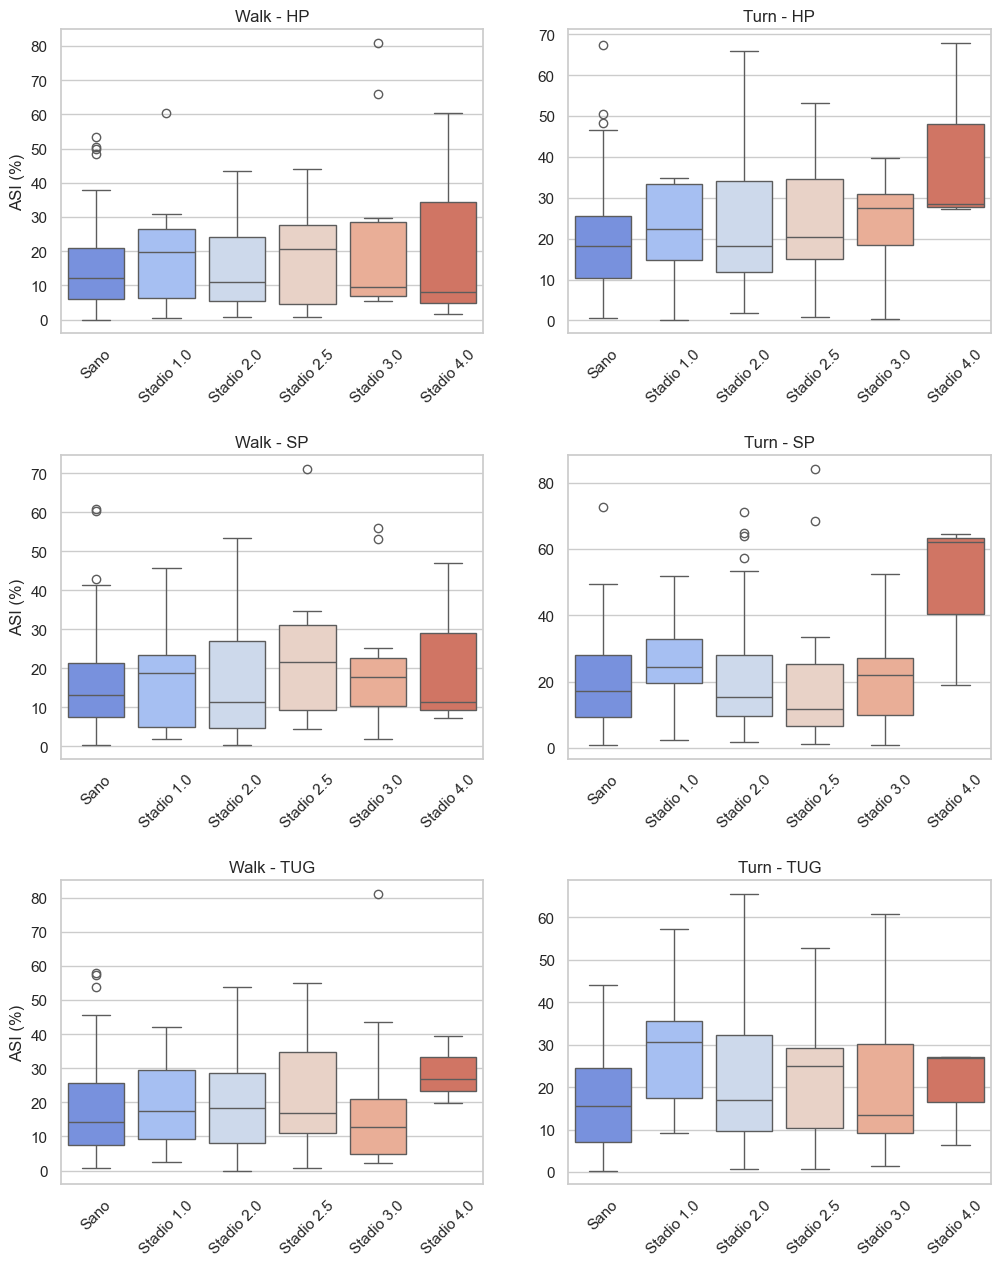

In [4]:
df_filtrato = df_pulito[df_pulito['H&Y'].astype(float) != 1.5].copy()

def crea_etichetta(row):
    if row['Gruppo'] == 'Sano':
        return 'Sano'
    else:
        return f"Stadio {float(row['H&Y'])}"

df_filtrato['Sottogruppo'] = df_filtrato.apply(crea_etichetta, axis=1)
stadi_malattia = sorted([s for s in df_filtrato['Sottogruppo'].unique() if s != 'Sano'])
ordine_x = ['Sano'] + stadi_malattia

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))
plt.subplots_adjust(hspace=0.4) 

tasks = ['HP', 'SP', 'TUG']

for i, task in enumerate(tasks):
    col_walk = f'ASI_Walk_{task} (%)'
    col_turn = f'ASI_Turn_{task} (%)'
    
    sns.boxplot(
        ax=axes[i, 0], data=df_filtrato, x='Sottogruppo', y=col_walk, 
        order=ordine_x, palette="coolwarm"
    )
    axes[i, 0].set_title(f'Walk - {task.upper()}')
    axes[i, 0].set_ylabel('ASI (%)')
    axes[i, 0].set_xlabel('')
    
    sns.boxplot(
        ax=axes[i, 1], data=df_filtrato, x='Sottogruppo', y=col_turn, 
        order=ordine_x, palette="coolwarm"
    )
    axes[i, 1].set_title(f'Turn - {task.upper()}')
    axes[i, 1].set_ylabel('')
    axes[i, 1].set_xlabel('')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.show()

### VALIDAZIONE STATISTICA DEI DATI - analisi velocità, falcata, durata e cadenza ###

In [5]:
nome_file = 'Dataset_Clinico_Pulito.csv' 
df_raw = pd.read_csv(nome_file, encoding='latin1') 

colonne_da_tenere = [
    'ID_Paziente', 'Gruppo', 'H&Y', 'Sesso', 'Eta', 'Peso', 'Altezza (cm)',
    'Durata_HP (s)', 'Velocita_HP (m/s)', 'Falcata_HP (m)', 'Cadenza_HP (passi/min)',
    'Durata_SP (s)', 'Velocita_SP (m/s)', 'Falcata_SP (m)', 'Cadenza_SP (passi/min)',
    'Durata_TUG (s)', 'Velocita_TUG (m/s)', 'Falcata_TUG (m)', 'Cadenza_TUG (passi/min)'
]

df = df_raw[colonne_da_tenere].copy()

mappa_colonne = {
    'ID_Paziente': 'ID_Paziente',
    'Gruppo': 'Gruppo',
    'H&Y': 'HY_Unificato',
    'Sesso': 'Sesso',
    'Eta': 'Eta',
    'Peso(kg)': 'Peso',
    'Altezza (cm)': 'Altezza',
    'Durata_HP (s)': 'Durata_Hurried',
    'Velocita_HP (m/s)': 'Velocita_Hurried', 
    'Falcata_HP (m)': 'Falcata_Hurried',
    'Cadenza_HP (passi/min)': 'Cadenza_Hurried',
    'Durata_SP (s)': 'Durata_Self',
    'Velocita_SP (m/s)': 'Velocita_Self',
    'Falcata_SP (m)': 'Falcata_Self',
    'Cadenza_SP (passi/min)': 'Cadenza_Self',
    'Durata_TUG (s)': 'Durata_TUG',
    'Velocita_TUG (m/s)': 'Velocita_TUG',
    'Falcata_TUG (m)': 'Falcata_TUG',
    'Cadenza_TUG (passi/min)': 'Cadenza_TUG'
}

df.rename(columns=mappa_colonne, inplace=True)
pazienti_iniziali = len(df)
df_clean = df.dropna(subset=['HY_Unificato', 'Eta']).copy()

pazienti_finali = len(df_clean)
scartati = pazienti_iniziali - pazienti_finali

print("\ndati puliti:")
print(f"Pazienti grezzi totali: {pazienti_iniziali}")
print(f"Pazienti scartati (dati essenziali mancanti): {scartati}")
print(f"Pazienti validi pronti per l'analisi: {pazienti_finali}")

print("\nVerifica della distribuzione dei pazienti per stadio Parkinson (HY_Unificato):")
print(df_clean['HY_Unificato'].value_counts().sort_index())


dati puliti:
Pazienti grezzi totali: 182
Pazienti scartati (dati essenziali mancanti): 5
Pazienti validi pronti per l'analisi: 177

Verifica della distribuzione dei pazienti per stadio Parkinson (HY_Unificato):
HY_Unificato
0.0    85
1.0     9
1.5     1
2.0    55
2.5    12
3.0    12
4.0     3
Name: count, dtype: int64


In [6]:
metriche_da_analizzare = [
    'Durata_Hurried', 'Velocita_Hurried', 'Falcata_Hurried', 'Cadenza_Hurried',
    'Durata_Self', 'Velocita_Self', 'Falcata_Self', 'Cadenza_Self',
    'Durata_TUG', 'Velocita_TUG', 'Falcata_TUG', 'Cadenza_TUG'
]

modelli_addestrati = {}

for metrica in metriche_da_analizzare:
    formula = f"{metrica} ~ bs(Eta, df=3) + HY_Unificato"
    modello = smf.ols(formula, data=df_clean).fit()
    modelli_addestrati[metrica] = modello

def format_p(val):
    if val < 0.001: return "< 0.001 ***"
    elif val < 0.01: return f"{val:.3f} **"
    elif val < 0.05: return f"{val:.3f} *"
    else: return f"{val:.3f}"

risultati_finali = []

for metrica, modello in modelli_addestrati.items():

    coef_parkinson = modello.params['HY_Unificato']
    p_value_grezzo = modello.pvalues['HY_Unificato']

    risultati_finali.append({
        "Test Motorio": metrica.split('_')[1],
        "Parametro": metrica.split('_')[0],
        "Coef_HY": round(coef_parkinson, 4),
        "P-value": format_p(p_value_grezzo)
    })

df_risultati = pd.DataFrame(risultati_finali)

display(df_risultati)

,Test Motorio,Parametro,Coef_HY,P-value
0,Hurried,Durata,1.8080,< 0.001 ***
1,Hurried,Velocita,-0.0394,0.001 **
2,Hurried,Falcata,-0.0519,< 0.001 ***
3,Hurried,Cadenza,-0.7601,0.363
4,Self,Durata,2.0664,< 0.001 ***
5,Self,Velocita,-0.0314,< 0.001 ***
6,Self,Falcata,-0.0547,< 0.001 ***
7,Self,Cadenza,-0.0048,0.994
8,TUG,Durata,2.0570,< 0.001 ***
9,TUG,Velocita,-0.0197,0.141


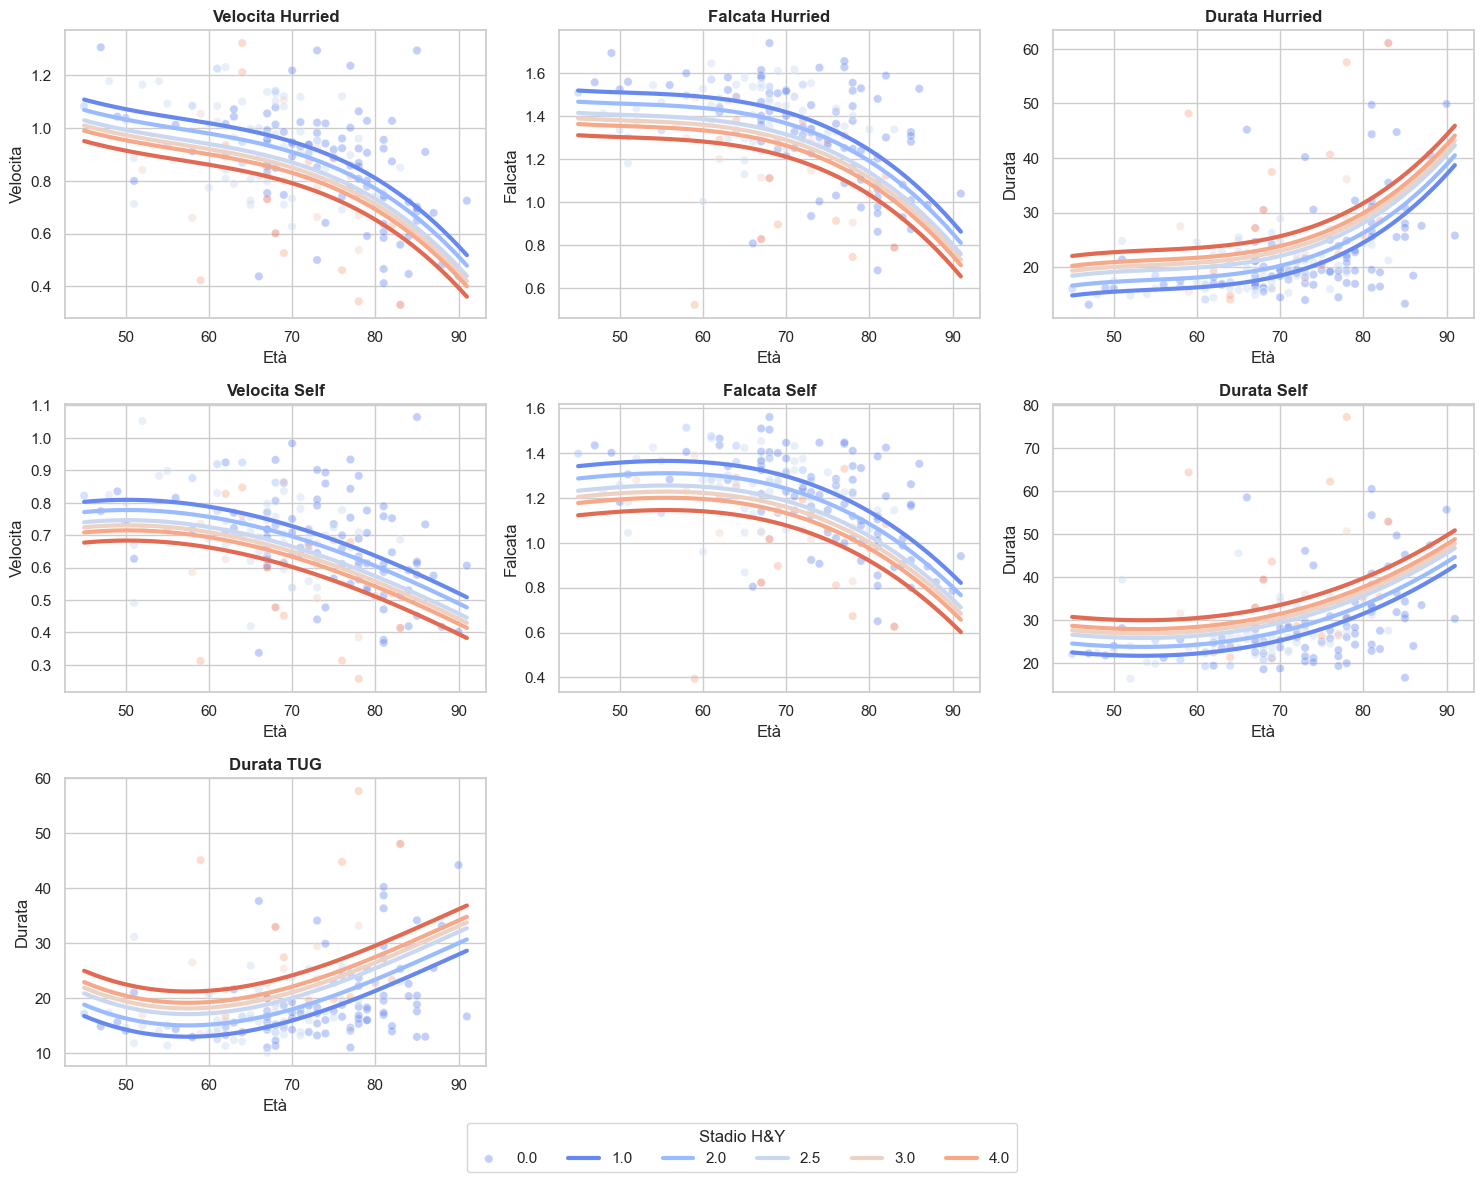

In [7]:
df_plot = df_clean[df_clean['HY_Unificato'] != 1.5]
stadi = sorted(df_plot['HY_Unificato'].unique())
colori = sns.color_palette("coolwarm", len(stadi))
color_dict = dict(zip(stadi, colori))

metriche = [
    'Velocita_Hurried', 'Falcata_Hurried', 'Durata_Hurried',
    'Velocita_Self', 'Falcata_Self', 'Durata_Self',
    'Durata_TUG'
]
sns.set_theme(style="whitegrid")
fig, assi = plt.subplots(3, 3, figsize=(15, 12))
assi = assi.flatten()

eta_x = np.linspace(df_plot['Eta'].min(), df_plot['Eta'].max(), 50)

for i, metrica in enumerate(metriche):
    ax = assi[i]

    sns.scatterplot(data=df_plot, x='Eta', y=metrica, hue='HY_Unificato', 
                    palette=color_dict, alpha=0.4, ax=ax, legend=False)

    modello = modelli_addestrati[metrica]
    for hy in stadi:
        pred_y = modello.predict(pd.DataFrame({'Eta': eta_x, 'HY_Unificato': hy}))
        ax.plot(eta_x, pred_y, linewidth=3, color=color_dict[hy])

    ax.set_title(metrica.replace('_', ' '), fontweight='bold')
    ax.set_ylabel(metrica.split('_')[0])
    ax.set_xlabel("Età")

assi[7].axis('off')
assi[8].axis('off')

fig.legend(stadi, loc='lower center', ncol=len(stadi), title="Stadio H&Y", bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### MODELLAZIONE PREDITTIVA E INTELLIGENZA ARTIFICIALE ###

Accuratezza modello (Test Set): 75.47%

10 parametri più influenti:
          Feature      Peso
              Eta -1.064591
   Falcata_SP (m) -0.905238
  Falcata_TUG (m)  0.868748
     Altezza (cm)  0.796726
             Peso -0.740160
Velocita_SP (m/s) -0.571528
    Durata_SP (s) -0.531419
    Durata_HP (s) -0.477593
   Durata_TUG (s)  0.455154
  ASI_Turn_HP (%)  0.376390




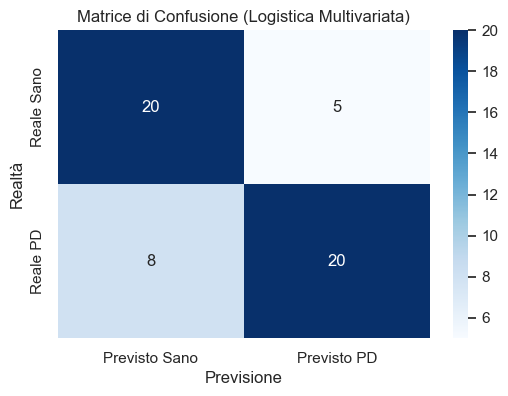

In [8]:
file_name = 'Dataset_Clinico_Pulito.csv'
df = pd.read_csv(file_name, encoding='latin1')

#2. Pulizia
#tolgo ID, sesso e le variabili cliniche (come H&Y e Gruppo) per evitare "data leakage"
col_escluse = ['ID_Paziente', 'Gruppo', 'Sesso', 'H&Y']

#elimino i valori mancanti
df_clean = df.dropna().reset_index(drop=True)

#X prende tutte colonne tenendo conto di tutti i dati a disposizione
X = df_clean.drop(columns=col_escluse)
#target: 1 se c'è scritto Parkinson, 0 altrimenti
y = df_clean['Gruppo'].apply(lambda x: 1 if 'Parkinson' in str(x) else 0)

#mi tengo da parte i dati veri per compilare l'excel finale
id_pazienti = df_clean['ID_Paziente'].values
diag_reale = df_clean['Gruppo'].values

#3. DIVISIONE E STANDARDIZZAZIONE DATI necessaria per il confronto
#split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#lo scaling qui è obbligatorio, sennò i parametri con valori assoluti grandi sballano i pesi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X) #lo uso alla fine per l'export su tutti i pazienti

#4. Specifico il modello
#alzo max_iter a 1000 perché con tante variabili a volte l'algoritmo fa fatica a convergere
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

#calcolo ACCURATEZZA sul test set
y_pred = log_reg.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuratezza modello (Test Set): {acc * 100:.2f}%\n")

#5. PESO delle caratteristiche nel modello
print("10 parametri più influenti:")
pesi = pd.DataFrame({'Feature': X.columns, 'Peso': log_reg.coef_[0]})
pesi['Importanza'] = pesi['Peso'].abs()
#ordino per valore assoluto per vedere chi impatta di più, in positivo o negativo
pesi_ordinati = pesi.sort_values(by='Importanza', ascending=False)
print(pesi_ordinati[['Feature', 'Peso']].head(10).to_string(index=False))
print("\n")

#6. Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto Sano', 'Previsto PD'], 
            yticklabels=['Reale Sano', 'Reale PD'])
plt.title('Matrice di Confusione (Logistica Multivariata)')
plt.ylabel('Realtà')
plt.xlabel('Previsione')
plt.show()

#7. Salvataggio risultati 
risultati = []

for i in range(len(X_all_scaled)):
    paziente = X_all_scaled[i].reshape(1, -1)
    
    pred = log_reg.predict(paziente)[0]
    prob = log_reg.predict_proba(paziente)[0][1] * 100
    
    esito = "Sospetto PD" if pred == 1 else "Sano"

    risultati.append({
        'ID_Paziente': id_pazienti[i],
        'Diagnosi_Reale': diag_reale[i],
        'Previsione_Modello': esito,
        'Probabilità_Malattia_%': round(prob, 1)
    })

df_risultati = pd.DataFrame(risultati)
out_file = 'Risultati_Logistica_TabellaCompleta.xlsx'
df_risultati.to_excel(out_file, index=False)

RISULTATI ACCURATEZZA:
Reg. Logistica     : 75.47%
Albero Decisionale : 67.92%
PLS                : 77.36%


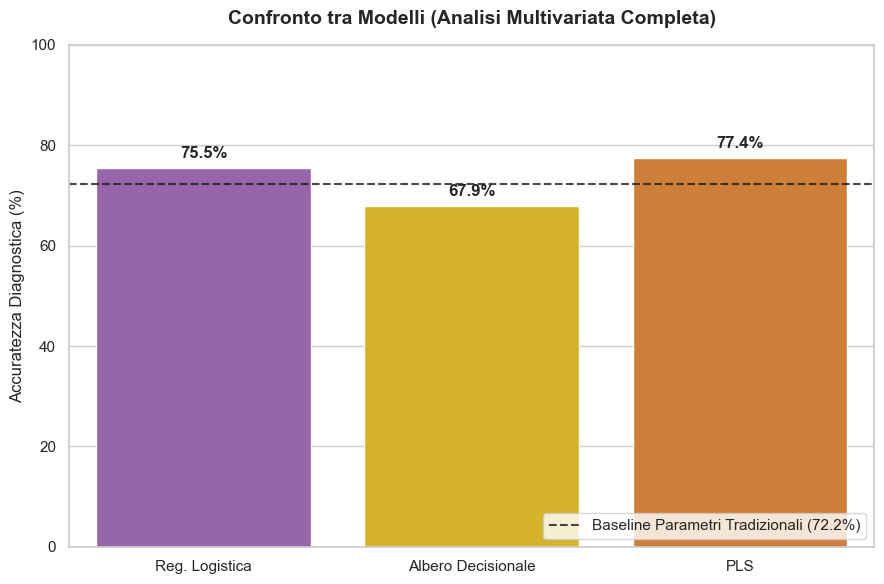

In [9]:
try:
    file_name = 'Dataset_Clinico_Pulito.csv'
    df = pd.read_csv(file_name,encoding='latin1')

    #2. PREPARAZIONE DATI 
    colonne_da_escludere = ['ID_Paziente', 'Gruppo', 'Sesso', 'H&Y']
    
    df_ml = df.dropna().reset_index(drop=True)
    
    X = df_ml.drop(columns=colonne_da_escludere)
    
    y = df_ml['Gruppo'].apply(lambda x: 1 if 'Parkinson' in str(x) else 0)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #MODELLO 1: REGRESSIONE LOGISTICA (Multivariata)
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    acc_lr = accuracy_score(y_test, lr.predict(X_test_scaled))

    #MODELLO 2: ALBERI DECISIONALI
    dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
    dt.fit(X_train_scaled, y_train)
    acc_dt = accuracy_score(y_test, dt.predict(X_test_scaled))

    #MODELLO 3: MINIMI QUADRATI (PLS Regression)
    pls = PLSRegression(n_components=2)
    pls.fit(X_train_scaled, y_train)
    #Il PLS restituisce valori continui, li convertiamo in classi (0 o 1) con soglia 0.5
    pls_preds = (pls.predict(X_test_scaled) > 0.5).astype(int).flatten()
    acc_pls = accuracy_score(y_test, pls_preds)

    #4. STAMPA DEI RISULTATI A SCHERMO
    print("RISULTATI ACCURATEZZA:")
    print(f"Reg. Logistica     : {acc_lr * 100:.2f}%")
    print(f"Albero Decisionale : {acc_dt * 100:.2f}%")
    print(f"PLS                : {acc_pls * 100:.2f}%")

    #5. PLOT GRAFICO 
    modelli = ['Reg. Logistica', 'Albero Decisionale', 'PLS']
    acc_scores = [acc_lr * 100, acc_dt * 100, acc_pls * 100]

    plt.figure(figsize=(9, 6))
    sns.barplot(x=modelli, y=acc_scores, hue=modelli, palette=['#9b59b6', '#f1c40f', '#e67e22'], legend=False)
    plt.ylim(0, 100)
    plt.title('Confronto tra Modelli (Analisi Multivariata Completa)', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Accuratezza Diagnostica (%)', fontsize=12)
    
    plt.axhline(y=72.22, color='k', linestyle='--', alpha=0.8, label='Baseline Parametri Tradizionali (72.2%)')
    plt.legend(loc='lower right')

    for i, v in enumerate(acc_scores):
        plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Errore: {e}")

CONFRONTO MODELLI:
Baseline Storica (Solo 4 param. base) : 72.22%
Random Forest (Base) su tutti i dati  : 75.47%
Random Forest (SMOTE) su tutti i dati : 73.58%


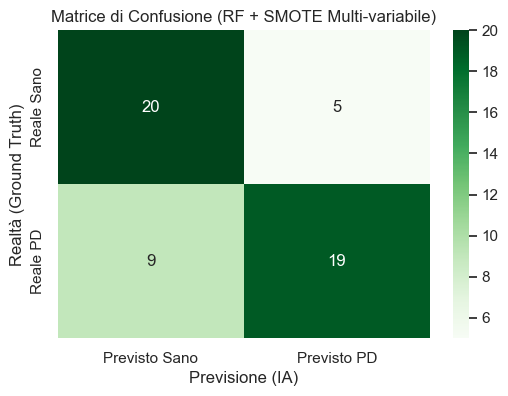


CLASSIFICA CARATTERISTICHE per importanza:
- Eta: 9.8%
- ASI_Turn_HP (%): 7.9%
- ASI_Turn_TUG (%): 7.8%
- Falcata_SP (m): 6.7%
- Falcata_TUG (m): 6.4%
- Altezza (cm): 6.0%
- Cadenza_TUG (passi/min): 4.7%
- Velocita_TUG (m/s): 4.5%
- ASI_Walk_SP (%): 4.3%
- ASI_Turn_SP (%): 4.1%


In [15]:
try:
    file_name = 'Dataset_Clinico_Pulito.csv'
    df = pd.read_csv(file_name,encoding='latin1')

    #2. PREPARAZIONE DATI
    colonne_da_escludere = ['ID_Paziente', 'Gruppo', 'Sesso', 'H&Y']
    df_ml = df.dropna().reset_index(drop=True)

    X = df_ml.drop(columns=colonne_da_escludere)
    #y target: 1 se Parkinson, 0 se Sano
    y = df_ml['Gruppo'].apply(lambda x: 1 if 'Parkinson' in str(x) else 0)

    features_list = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #MODELLO 1: RANDOM FOREST CLASSICO
    rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_base.fit(X_train_scaled, y_train)
    acc_base = accuracy_score(y_test, rf_base.predict(X_test_scaled))

    #2. OVERSAMPLING CON SMOTE 
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

    #3. RANDOM FOREST SU DATI BILANCIATI (SMOTE)
    rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_smote.fit(X_train_sm, y_train_sm)
    y_pred_smote = rf_smote.predict(X_test_scaled)
    acc_smote = accuracy_score(y_test, y_pred_smote)

    print("CONFRONTO MODELLI:")
    print("Baseline Storica (Solo 4 param. base) : 72.22%")
    print(f"Random Forest (Base) su tutti i dati  : {acc_base * 100:.2f}%")
    print(f"Random Forest (SMOTE) su tutti i dati : {acc_smote * 100:.2f}%")
    
    #MATRICE DI CONFUSIONE
    cm = confusion_matrix(y_test, y_pred_smote)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Previsto Sano', 'Previsto PD'], 
                yticklabels=['Reale Sano', 'Reale PD'])
    plt.title('Matrice di Confusione (RF + SMOTE Multi-variabile)')
    plt.ylabel('Realtà (Ground Truth)')
    plt.xlabel('Previsione (IA)')
    plt.show()

    #IMPORTANZA DELLE CARATTERISTICHE
    print("\nCLASSIFICA CARATTERISTICHE per importanza:")
    feat_imp = pd.DataFrame({
        'Feature': features_list, 
        'Importance (%)': rf_smote.feature_importances_ * 100
    }).sort_values(by='Importance (%)', ascending=False)

    for _, row in feat_imp.head(10).iterrows():
        print(f"- {row['Feature']}: {row['Importance (%)']:.1f}%")

except Exception as e:
    print(f"Errore: {e}")


df_risultati = pd.DataFrame(risultati)
out_file = 'Risultati_Random_Forest.xlsx'
df_risultati.to_excel(out_file, index=False)

Voti dei 5 test separati : [np.float64(74.3), np.float64(48.6), np.float64(68.6), np.float64(91.4), np.float64(68.6)] %
ACCURATEZZA MEDIA REALE: 70.29%



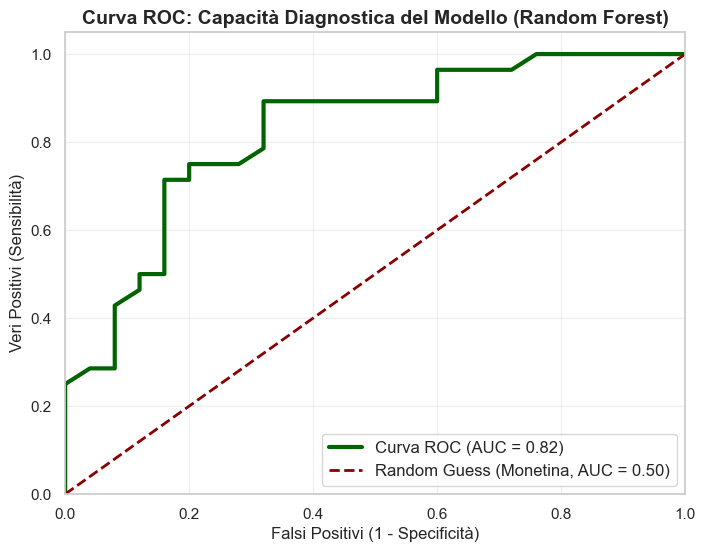

In [11]:
try:
    #1. CARICAMENTO DATI
    file_name = 'Dataset_Clinico_Pulito.csv'
    df = pd.read_csv(file_name, encoding='latin1')
    colonne_da_escludere = ['ID_Paziente', 'Gruppo', 'Sesso', 'H&Y']
    df_ml = df.dropna().reset_index(drop=True)

    X = df_ml.drop(columns=colonne_da_escludere)
    y = df_ml['Gruppo'].apply(lambda x: 1 if 'Parkinson' in str(x) else 0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    #2. K-FOLD CROSS VALIDATION 
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf_cv = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

    scores = cross_val_score(rf_cv, X_scaled, y, cv=cv, scoring='accuracy')

    print(f"Voti dei 5 test separati : {[round(s*100, 1) for s in scores]} %")
    print(f"ACCURATEZZA MEDIA REALE: {scores.mean()*100:.2f}%\n")

    #3. CURVA ROC E INDICE AUC 
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    rf_roc = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_roc.fit(X_train, y_train)

    y_probs = rf_roc.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkgreen', lw=3, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='darkred', lw=2, linestyle='--', label='Random Guess (Monetina, AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Falsi Positivi (1 - Specificità)', fontsize=12)
    plt.ylabel('Veri Positivi (Sensibilità)', fontsize=12)
    plt.title('Curva ROC: Capacità Diagnostica del Modello (Random Forest)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Errore: {e}")

### STRUTTURAZIONE DATI, STANDARD HL7 CDA R2, INTEROPERABILITA' E VALIDAZIONE ###


In [12]:
df = pd.read_csv("Dataset_Clinico_Pulito.csv",encoding='latin1')

df_clinico_c = pd.read_csv("controls - demographic+clinical - datasetv1.csv",skiprows=1)
df_clinico_c.set_index("Subject ID", inplace=True)

df_clinico_pd = pd.read_csv("pd - demographic+clinical - datasetv1.csv",skiprows=1)
df_clinico_pd.set_index("Subject ID", inplace=True)

df_rf = pd.read_excel("Risultati_Random_Forest.xlsx")
df_rf.columns = df_rf.columns.str.strip()
df_rf.set_index("ID_Paziente", inplace=True)

In [13]:
file_loader = FileSystemLoader('.')
env = Environment(loader=file_loader)
template = env.get_template('cda_tv_codici_locali.xml')
counter = 0

for index, riga in df.iterrows():
    counter += 1
    id_corrente = riga['ID_Paziente']

    anni_diagnosi = 'UN'
    medicazione = 'UN'
    data_diagnosi = 'UN'
    
    if id_corrente in df_clinico_c.index:
        riga_paziente = df_clinico_c.loc[id_corrente]
        anni_diagnosi = 0
        medicazione = riga_paziente['Current Medications [type][dosage]']
        data_diagnosi = 'UN'
        
    elif id_corrente in df_clinico_pd.index:
        riga_paziente = df_clinico_pd.loc[id_corrente]
        anni_diagnosi = riga_paziente['Years since PD diagnosis'] 
        medicazione = riga_paziente['Current Medications']
        try:
            anni_diagnosi_num = float(anni_diagnosi)
            data_diagnosi = 2024 - anni_diagnosi_num
        except (ValueError, TypeError):
            data_diagnosi = 'UN'
        
    else:
        anni_diagnosi = 'UN'
        medicazione = 'UN'
        data_diagnosi = 'UN'

    try:
        riga_clinica = df_rf.loc[id_corrente]
        previsione_modello_rf = riga_clinica['Previsione_Modello']
        probabilità_malattia_rf = riga_clinica['Probabilità_Malattia_%']
   
    except KeyError:
        previsione_modello_rf = 'UNK'
        probabilità_malattia_rf = 'UNK'

    valore_gender = str(riga['Sesso']).strip().lower()
    if valore_gender == 'male':
        c_sesso = "M"
    elif valore_gender == 'female':
        c_sesso = "F"
    else:
        c_sesso = "UN"

    ora = datetime.now()
    data_formattata = ora.strftime("%Y%m%d%H%M") 
    if data_diagnosi != 'UN':
        oggetto_data = datetime(year=int(data_diagnosi), month=1, day=1, hour=0, minute=0)
        data_diagnosi_formattata = oggetto_data.strftime("%Y%m%d%H%M")
    else:
        data_diagnosi_formattata = data_diagnosi
  
    eta = riga['Eta']
    anno_nascita = 2024-eta
    partita_iva = 11234560153

    
    
    dati = {
        "partita_iva": partita_iva,
        "data_diagnosi": data_diagnosi_formattata,
        "data_creazione": data_formattata,
        "id_paziente": riga['ID_Paziente'], 
        "versione": "1",
        "id_documento": f"REP_{riga['ID_Paziente']}",
        "codice_sesso": c_sesso,
        "sesso": riga['Sesso'],
        "data_nascita":anno_nascita,
        "codice_fiscale_autore_1":"GZZSML04S02C794N",  
        "data_inizio_test":data_formattata,
        "data_fine_test":data_formattata,
        "eta_paziente":riga['Eta'],
        "peso_paziente":riga['Peso'],
        "altezza_paziente":riga['Altezza (cm)'],
        "anni_diagnosi":anni_diagnosi,
        "HoehnYahr":riga['H&Y'],
        "medicazione":medicazione,
        "Walk_Time_TUG":riga['Durata_TUG (s)'],
        "Gait_Velocity_TUG":riga['Velocita_TUG (m/s)'],
        "Cadenza_TUG":riga['Cadenza_TUG (passi/min)'],
        "Lunghezza_falcata_TUG":riga['Falcata_TUG (m)'],
        "Walk_Time_SP":riga['Durata_SP (s)'],
        "Gait_Velocity_SP":riga['Velocita_SP (m/s)'],
        "Cadenza_SP":riga['Cadenza_SP (passi/min)'],
        "Lunghezza_falcata_SP":riga['Falcata_SP (m)'],
        "Walk_Time_HP":riga['Durata_HP (s)'],
        "Gait_Velocity_HP":riga['Velocita_HP (m/s)'],
        "Cadenza_HP":riga['Cadenza_HP (passi/min)'],
        "Lunghezza_falcata_HP":riga['Falcata_HP (m)'], 
        "Predizione_ML":previsione_modello_rf,
        "Probabilita_ML":probabilità_malattia_rf,    
        "ASI_WALK_HP":riga['ASI_Walk_HP (%)'],
        "ASI_TURN_HP":riga['ASI_Turn_HP (%)'],
        "ASI_WALK_SP":riga['ASI_Walk_SP (%)'], 
        "ASI_TURN_SP":riga['ASI_Turn_SP (%)'],
        "ASI_WALK_TUG":riga['ASI_Walk_TUG (%)'],
        "ASI_TURN_TUG":riga['ASI_Turn_TUG (%)'],
        "diagnosi_paziente": riga['Gruppo'],
    }
    output = template.render(dati)
    nome_file = f"CDA_Paziente_{riga['ID_Paziente']}.xml"
    with open(nome_file,"w", encoding="utf-8") as f:
        f.write(output)
    print(f"[{counter}]File{nome_file} generato con successo")

[1]FileCDA_Paziente_HC100.xml generato con successo
[2]FileCDA_Paziente_HC101.xml generato con successo
[3]FileCDA_Paziente_HC102.xml generato con successo
[4]FileCDA_Paziente_HC103.xml generato con successo
[5]FileCDA_Paziente_HC104.xml generato con successo
[6]FileCDA_Paziente_HC105.xml generato con successo
[7]FileCDA_Paziente_HC106.xml generato con successo
[8]FileCDA_Paziente_HC107.xml generato con successo
[9]FileCDA_Paziente_HC108.xml generato con successo
[10]FileCDA_Paziente_HC109.xml generato con successo
[11]FileCDA_Paziente_HC110.xml generato con successo
[12]FileCDA_Paziente_HC111.xml generato con successo
[13]FileCDA_Paziente_HC112.xml generato con successo
[14]FileCDA_Paziente_HC113.xml generato con successo
[15]FileCDA_Paziente_HC114.xml generato con successo
[16]FileCDA_Paziente_HC115.xml generato con successo
[17]FileCDA_Paziente_HC116.xml generato con successo
[18]FileCDA_Paziente_HC117.xml generato con successo
[19]FileCDA_Paziente_HC118.xml generato con successo
[2

In [14]:
file_loader = FileSystemLoader('.')
env = Environment(loader=file_loader)
template = env.get_template('cda_pss_codici_locali.xml')
counter = 0

for index, riga in df.iterrows():
    counter += 1
    id_corrente = riga['ID_Paziente']

    anni_diagnosi = 'UN'
    medicazione = 'UN'
    data_diagnosi = 'UN'
    
    if id_corrente in df_clinico_c.index:
        riga_paziente = df_clinico_c.loc[id_corrente]
        anni_diagnosi = 0
        medicazione = riga_paziente['Current Medications [type][dosage]']
        data_diagnosi = 'UN'
        
    elif id_corrente in df_clinico_pd.index:
        riga_paziente = df_clinico_pd.loc[id_corrente]
        anni_diagnosi = riga_paziente['Years since PD diagnosis'] 
        medicazione = riga_paziente['Current Medications']
        try:
            anni_diagnosi_num = float(anni_diagnosi)
            data_diagnosi = 2024 - anni_diagnosi_num
        except (ValueError, TypeError):
            data_diagnosi = 'UN'
        
    else:
        anni_diagnosi = 'UN'
        medicazione = 'UN'
        data_diagnosi = 'UN'

    try:
        riga_clinica = df_rf.loc[id_corrente]
        previsione_modello_rf = riga_clinica['Previsione_Modello']
        probabilità_malattia_rf = riga_clinica['Probabilità_Malattia_%']
   
    except KeyError:
        previsione_modello_rf = 'UNK'
        probabilità_malattia_rf = 'UNK'

    valore_gender = str(riga['Sesso']).strip().lower()
    if valore_gender == 'male':
        c_sesso = "M"
    elif valore_gender == 'female':
        c_sesso = "F"
    else:
        c_sesso = "UN"

    ora = datetime.now()
    data_formattata = ora.strftime("%Y%m%d%H%M")
    if data_diagnosi != 'UN':
        oggetto_data = datetime(year=int(data_diagnosi), month=1, day=1, hour=0, minute=0)
        data_diagnosi_formattata = oggetto_data.strftime("%Y%m%d%H%M")
    else:
        data_diagnosi_formattata = data_diagnosi
  
    eta = riga['Eta']
    anno_nascita = 2024-eta
    partita_iva = 11234560153
    
    dati = {
        "partita_iva": partita_iva,
        "data_diagnosi": data_diagnosi_formattata,
        "data_creazione": data_formattata,
        "id_paziente": riga['ID_Paziente'], 
        "versione": "1",
        "id_documento": f"REP_{riga['ID_Paziente']}",
        "codice_sesso": c_sesso,
        "sesso": riga['Sesso'],
        "data_nascita":anno_nascita,
        "codice_fiscale_autore_1":"GZZSML04S02C794N",  
        "data_inizio_test":data_formattata,
        "data_fine_test":data_formattata,
        "eta_paziente":riga['Eta'],
        "peso_paziente":riga['Peso'],
        "altezza_paziente":riga['Altezza (cm)'],
        "anni_diagnosi":anni_diagnosi,
        "HoehnYahr":riga['H&Y'],
        "medicazione":medicazione,
        "Walk_Time_TUG":riga['Durata_TUG (s)'],
        "Gait_Velocity_TUG":riga['Velocita_TUG (m/s)'],
        "Cadenza_TUG":riga['Cadenza_TUG (passi/min)'],
        "Lunghezza_falcata_TUG":riga['Falcata_TUG (m)'],
        "Walk_Time_SP":riga['Durata_SP (s)'],
        "Gait_Velocity_SP":riga['Velocita_SP (m/s)'],
        "Cadenza_SP":riga['Cadenza_SP (passi/min)'],
        "Lunghezza_falcata_SP":riga['Falcata_SP (m)'],
        "Walk_Time_HP":riga['Durata_HP (s)'],
        "Gait_Velocity_HP":riga['Velocita_HP (m/s)'],
        "Cadenza_HP":riga['Cadenza_HP (passi/min)'],
        "Lunghezza_falcata_HP":riga['Falcata_HP (m)'], 
        "Predizione_ML":previsione_modello_rf,
        "Probabilita_ML":probabilità_malattia_rf,    
        "ASI_WALK_HP":riga['ASI_Walk_HP (%)'],
        "ASI_TURN_HP":riga['ASI_Turn_HP (%)'],
        "ASI_WALK_SP":riga['ASI_Walk_SP (%)'], 
        "ASI_TURN_SP":riga['ASI_Turn_SP (%)'],
        "ASI_WALK_TUG":riga['ASI_Walk_TUG (%)'],
        "ASI_TURN_TUG":riga['ASI_Turn_TUG (%)'],
        "diagnosi_paziente": riga['Gruppo'],
    }
    output = template.render(dati)
    nome_file = f"PSS_Paziente_{riga['ID_Paziente']}.xml"
    with open(nome_file,"w", encoding="utf-8") as f:
        f.write(output)
    print(f"[{counter}]File{nome_file} generato con successo")

[1]FilePSS_Paziente_HC100.xml generato con successo
[2]FilePSS_Paziente_HC101.xml generato con successo
[3]FilePSS_Paziente_HC102.xml generato con successo
[4]FilePSS_Paziente_HC103.xml generato con successo
[5]FilePSS_Paziente_HC104.xml generato con successo
[6]FilePSS_Paziente_HC105.xml generato con successo
[7]FilePSS_Paziente_HC106.xml generato con successo
[8]FilePSS_Paziente_HC107.xml generato con successo
[9]FilePSS_Paziente_HC108.xml generato con successo
[10]FilePSS_Paziente_HC109.xml generato con successo
[11]FilePSS_Paziente_HC110.xml generato con successo
[12]FilePSS_Paziente_HC111.xml generato con successo
[13]FilePSS_Paziente_HC112.xml generato con successo
[14]FilePSS_Paziente_HC113.xml generato con successo
[15]FilePSS_Paziente_HC114.xml generato con successo
[16]FilePSS_Paziente_HC115.xml generato con successo
[17]FilePSS_Paziente_HC116.xml generato con successo
[18]FilePSS_Paziente_HC117.xml generato con successo
[19]FilePSS_Paziente_HC118.xml generato con successo
[2